* https://developer.apple.com/metal/tensorflow-plugin/
* https://www.youtube.com/watch?v=w2qlou7n7MA
* https://github.com/conda-forge/miniforge
* https://github.com/jeffheaton/t81_558_deep_learning/blob/master/install/tensorflow-install-mac-metal-jul-2021.ipynb
* https://github.com/jeffheaton/t81_558_deep_learning/blob/master/tensorflow-apple-metal.yml
* https://github.com/GPflow/GPflow
* `jupytext --to notebook regression.pct.py`

In [250]:
#pip install covasim gpflow

In [251]:
from mpl_toolkits import mplot3d

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
import gpflow as gpf
from gpflow.utilities import print_summary

# The lines below are specific to the notebook format
%matplotlib inline
#%matplotlib notebook
#%matplotlib qt
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams.update({'font.size': 24})

dtyp = np.float64
gpf.config.set_default_float(dtyp)

print("Tensorflow version " + tf.__version__)
print(f"Tensorflow Probability: {tfp.__version__}")
print(f"GPFlow {gpf.__version__}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "NOT AVAILABLE")

try:
  tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection
  print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])

  tf.config.experimental_connect_to_cluster(tpu)
  tf.tpu.experimental.initialize_tpu_system(tpu)
  tpu_strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
  msg = 'WARNING: Not connected to a TPU runtime; please see the previous cell in this notebook for instructions!'
  print(msg)

tf.config.experimental.set_visible_devices([], 'GPU') # Turn off GPU (for M1 Mac, hopefully temporary!)
#tf.config.set_soft_device_placement(True)
tf.debugging.set_log_device_placement(False)

print('Physical: ', tf.config.list_physical_devices())
print('Logical: ', tf.config.list_logical_devices())

Tensorflow version 2.8.0
Tensorflow Probability: 0.16.0
GPFlow 2.4.0
GPU is available
Physical:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical:  [LogicalDevice(name='/device:CPU:0', device_type='CPU')]


## Load training data

In [252]:
df = pd.read_csv('sweep_beta_popinf.csv')
df['log_popinf'] = np.log10(df['pop_infected'])
X1 = df['log_beta']
X2 = df['pop_infected']
X = df[['log_beta', 'pop_infected']].values.reshape(-1, 2).astype(dtyp)
Y = df['cum_inf'].values.reshape(-1, 1).astype(dtyp)

# Normalize
Y = Y-Y.mean()
Y = 2 * Y / (Y.max() - Y.min())

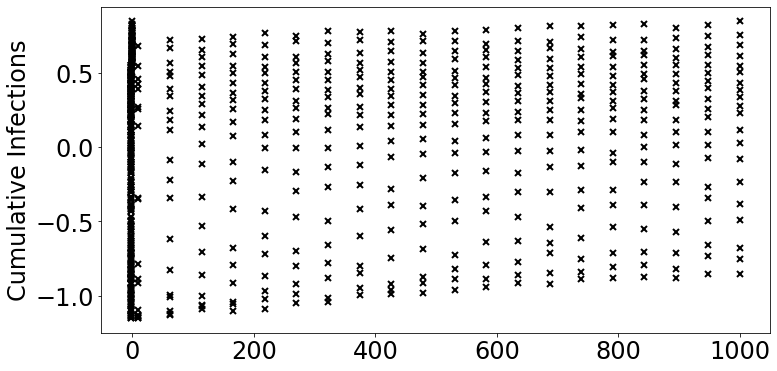

In [253]:
f, ax = plt.subplots();
ax.plot(X, Y, 'kx', mew=2);
ax.set_ylabel('Cumulative Infections');

In [259]:
k = gpf.kernels.Matern52(lengthscales=[0.3, 200])
print_summary(k)

╒═══════════════════════╤═══════════╤═════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════╕
│ name                  │ class     │ transform   │ prior   │ trainable   │ shape   │ dtype   │ value         │
╞═══════════════════════╪═══════════╪═════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════╡
│ Matern52.variance     │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │ 1.0           │
├───────────────────────┼───────────┼─────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ Matern52.lengthscales │ Parameter │ Softplus    │         │ True        │ (2,)    │ float64 │ [  0.3 200. ] │
╘═══════════════════════╧═══════════╧═════════════╧═════════╧═════════════╧═════════╧═════════╧═══════════════╛


In [260]:
m = gpf.models.GPR(data=(X, Y), kernel=k, mean_function=None)
m.likelihood.variance.assign(1)
#m.kernel.lengthscales.assign(0.3)
m.kernel.variance.assign(1)
print_summary(m)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value         │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0           │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ (2,)    │ float64 │ [  0.3 200. ] │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 1.0           │
╘═════════════════════════╧═══════════╧═════════

In [261]:
opt = gpf.optimizers.Scipy()

opt_logs = opt.minimize(m.training_loss, m.trainable_variables, options=dict(maxiter=10000))
print_summary(m)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                       │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0162780234205175          │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ (2,)    │ float64 │ [  0.7193489  391.38140765] │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ 

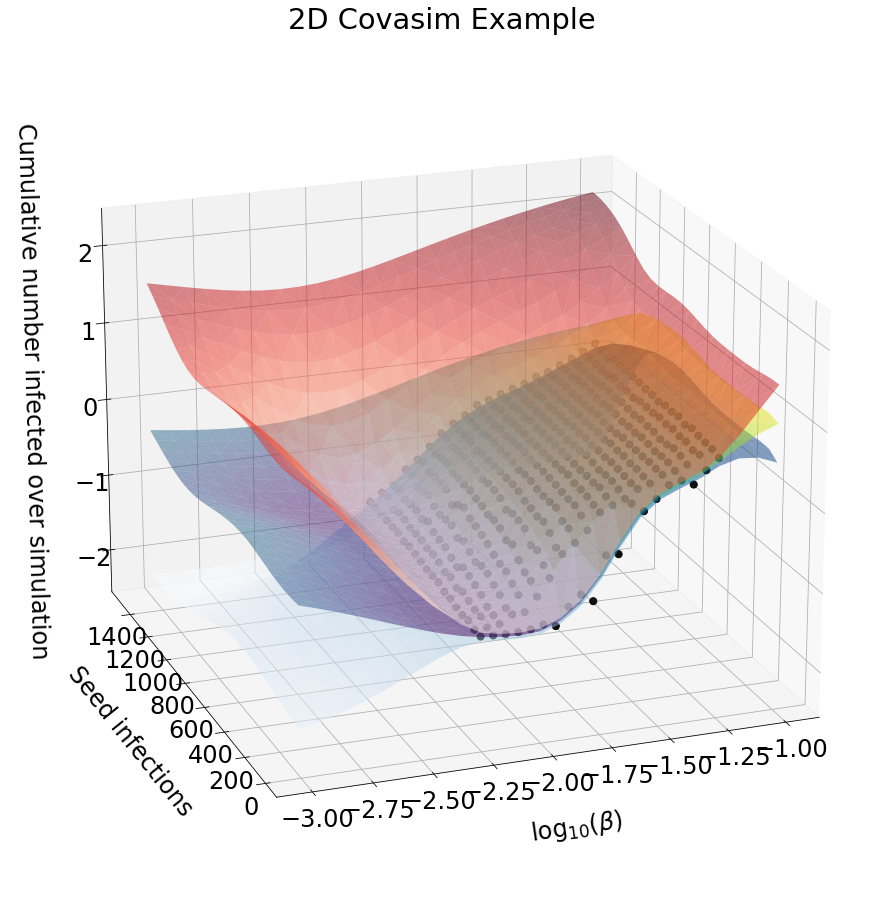

In [262]:
## generate test points for prediction
N = 25
x1 = np.log10(np.logspace(-3, -1, N))  # test points must be of shape (N, D)
x2 = np.linspace(5, 1500, N)  # test points must be of shape (N, D)
XX1, XX2 = np.meshgrid(x1, x2)
xx = np.stack([np.ravel(XX1), np.ravel(XX2)]).T.astype(dtyp)

#xx = np.stack([X1, X2]).T

## predict mean and variance of latent GP at test points
mean_f, var_f = m.predict_f(xx)
mean_y, var_y = m.predict_y(xx)

## generate 10 samples from posterior
#tf.random.set_seed(1)  # for reproducibility
#samples = m.predict_f_samples(xx, 10)  # shape (10, 100, 1)

fig = plt.figure(figsize=(16,16))
ax = plt.axes(projection='3d')
ax.scatter3D(X1, X2, Y, c='black', s=50);
ax.plot_trisurf(xx[:,0], xx[:,1], mean_f.numpy().squeeze(), cmap='viridis', edgecolor='none', alpha=0.5)
ax.plot_trisurf(xx[:,0], xx[:,1], mean_f.numpy().squeeze()+2*np.sqrt(var_f.numpy().squeeze()), cmap='Reds', edgecolor='none', alpha=0.5)
ax.plot_trisurf(xx[:,0], xx[:,1], mean_f.numpy().squeeze()-2*np.sqrt(var_f.numpy().squeeze()), cmap='Blues', edgecolor='none', alpha=0.5)
#ax.plot_trisurf(X1, X2, np.ravel(mean_f.numpy()), cmap='viridis', edgecolor='none', alpha=0.5)

ax.view_init(20, 250)
ax.set_title('2D Covasim Example');
ax.set_xlabel(r'$\log_{10}(\beta)$')
ax.set_ylabel('Seed infections')
ax.set_zlabel('Cumulative number infected over simulation')
ax.xaxis.labelpad = 30
ax.yaxis.labelpad = 30
ax.zaxis.labelpad = 30

Percent of points within two standard deviations: 97.5%.


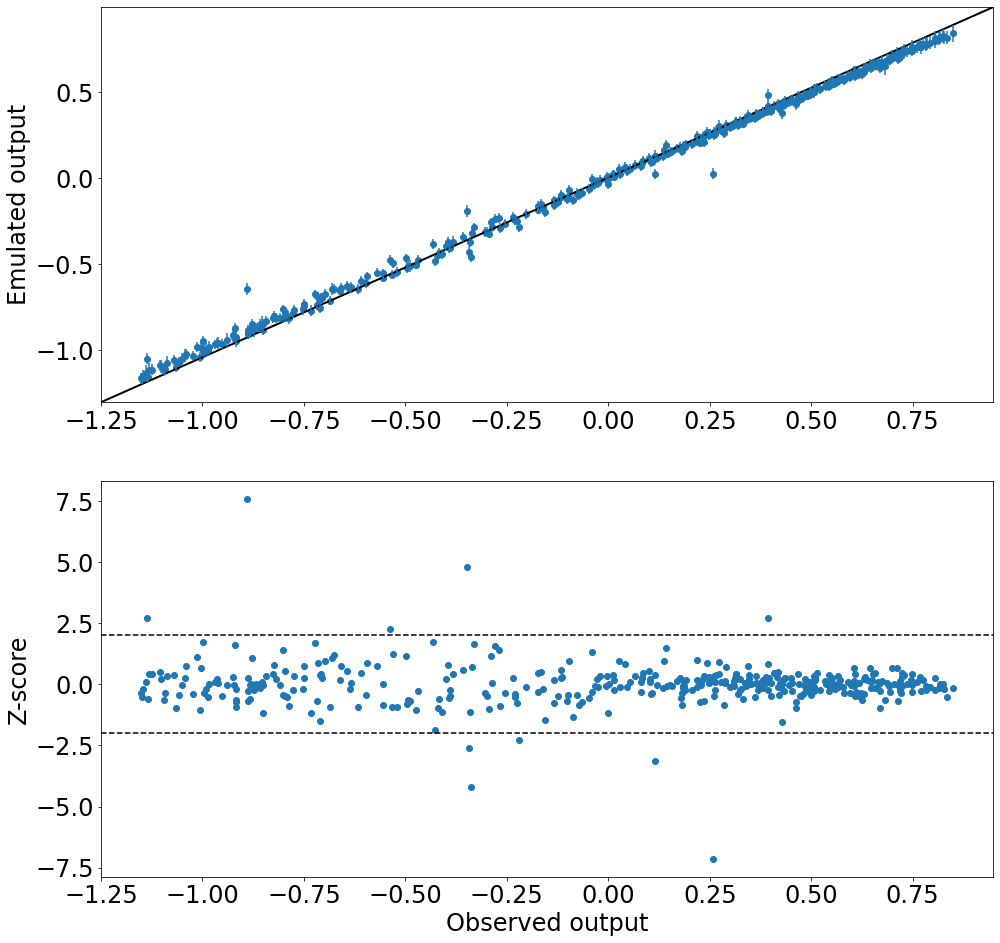

In [263]:
#i = 25
#mu, var = m.predict_f(X[i].reshape(-1, 2))
#print(X[i].reshape(-1, 2), Y[i], mu.numpy(), var.numpy())


mu, var_f = m.predict_f(X.reshape(-1, 2))
mu = mu.numpy().squeeze()
std_f = np.sqrt(var_f.numpy()).squeeze()
y = Y.squeeze()

fig, axv = plt.subplots(2,1, figsize=(16,16))

ax = axv[0]
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='k', lw=2)
ax.scatter(Y, mu)
ax.errorbar(x=y, y=mu, yerr=2*std_f, fmt='none')
ax.set_ylabel('Emulated output')

ax = axv[1]
z = (mu-y) / (2*std_f)

ax.scatter(y, z)
ax.axhline(y=-2, color='k', ls='--')
ax.axhline(y=2, color='k', ls='--')
ax.set_xlabel('Observed output')
ax.set_ylabel('Z-score')

print(f'Percent of points within two standard deviations: {sum(abs(z)<2) / len(z):.1%}.');